<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

In [29]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    ax = plt.subplot(1, len(images), i+1)
    if len(img.shape) == 2:
      plt.imshow(img, cmap='gray')
    else:
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

    for spine in ax.spines.values():
      spine.set_visible(True)
      spine.set_color('black')
      spine.set_linewidth(0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title)
  plt.show()

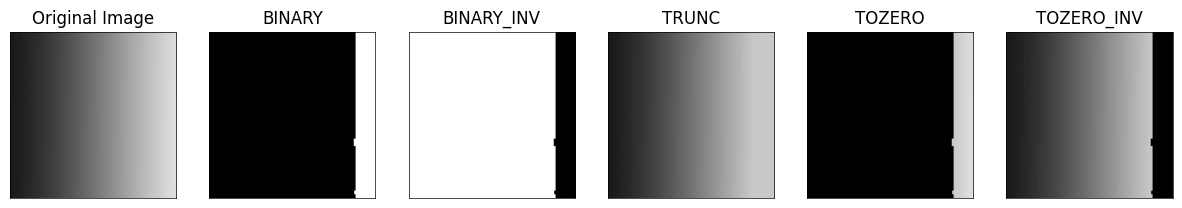

In [31]:
# Global Threshold (binary, binary inverse, trunc, tozero, tozero inverse)
img = cv.imread('/content/drive/MyDrive/PCVK2026/gradient.jpg')
thresh = 200
maxval = 255

# Implementasi Manual
binary = np.where(img > thresh, maxval, 0).astype(np.uint8)
binary_inv = np.where(img <= thresh, maxval, 0).astype(np.uint8)
trunc = np.where(img > thresh, thresh, img).astype(np.uint8)
tozero = np.where(img > thresh, img, 0).astype(np.uint8)
tozero_inv = np.where(img <= thresh, img, 0).astype(np.uint8)

# Plotting
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, binary, binary_inv, trunc, tozero, tozero_inv]
show_side_by_side(images, titles)